# IMDC 2026 — Dengue & Chikungunya EDA

State-level trends, seasonality, and cross-disease patterns. All modeling in this project targets the top-down state-aggregated series (see `src/imdc/data/aggregate.py`), so this notebook works at that same level throughout.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from imdc.config import FIGURES_DIR, MANDATORY_UFS
from imdc.data.loaders import load_cases
from imdc.data.aggregate import aggregate_cases_to_state

# Categorical/sequential colors per the project's validated palette
# (references/palette.md) - blue for dengue / primary sequential hue,
# red for chikungunya (categorical slots 1 and 6).
COLOR_DENGUE = "#2a78d6"
COLOR_CHIK = "#e34948"
COLOR_BAND = "#9ec5f4"   # sequential step 200, for IQR ribbons
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "font.size": 11,
})

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

dengue = load_cases("dengue")
chik = load_cases("chikungunya")
state_dengue = aggregate_cases_to_state(dengue)
state_chik = aggregate_cases_to_state(chik)
national_dengue = state_dengue.groupby("date", as_index=False)["casos"].sum()
national_chik = state_chik.groupby("date", as_index=False)["casos"].sum()
print(state_dengue.shape, state_chik.shape)

(21970, 3) (16562, 3)


## 1. National weekly case totals (26 mandatory states, ES excluded)

Single hue per series (2 series -> legend, no color-cycling of extra categories), one axis. Dengue and chikungunya differ by orders of magnitude and by data start date, so they're shown as two stacked panels sharing the x-axis rather than a dual y-axis.

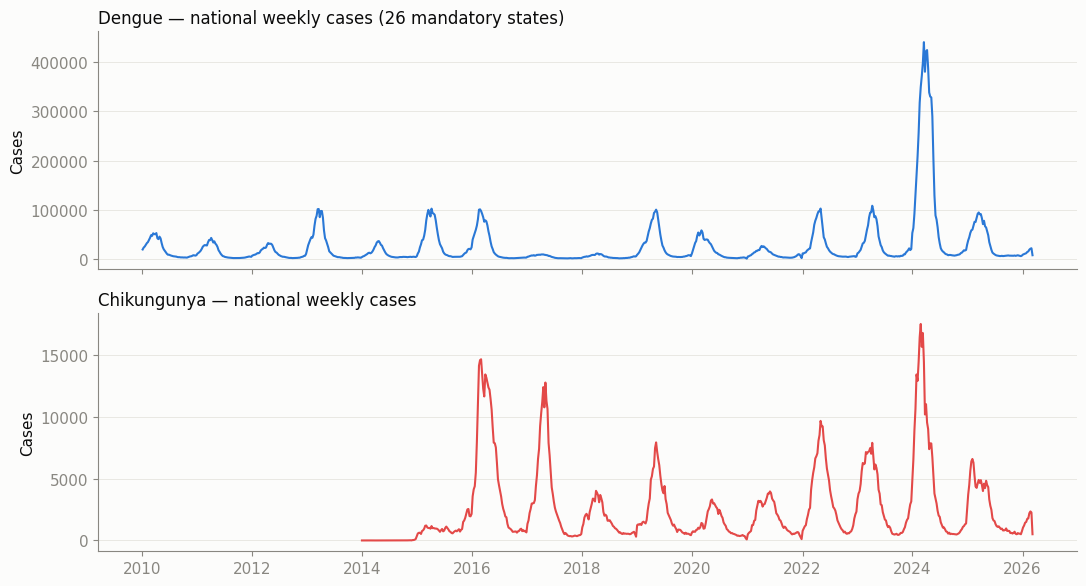

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(national_dengue["date"], national_dengue["casos"], color=COLOR_DENGUE, lw=1.5)
axes[0].set_title("Dengue — national weekly cases (26 mandatory states)", loc="left", fontsize=12)
axes[0].set_ylabel("Cases")
axes[0].grid(axis="y", lw=0.5)

axes[1].plot(national_chik["date"], national_chik["casos"], color=COLOR_CHIK, lw=1.5)
axes[1].set_title("Chikungunya — national weekly cases", loc="left", fontsize=12)
axes[1].set_ylabel("Cases")
axes[1].grid(axis="y", lw=0.5)
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "national_weekly_trends.png", dpi=150)
plt.show()

## 2. Seasonal climatology — median + IQR by epidemiological week

A one-hue ribbon (median line + interquartile band across all observed years) is the standard way to show "typical seasonal shape plus spread" without a rainbow of per-year lines.

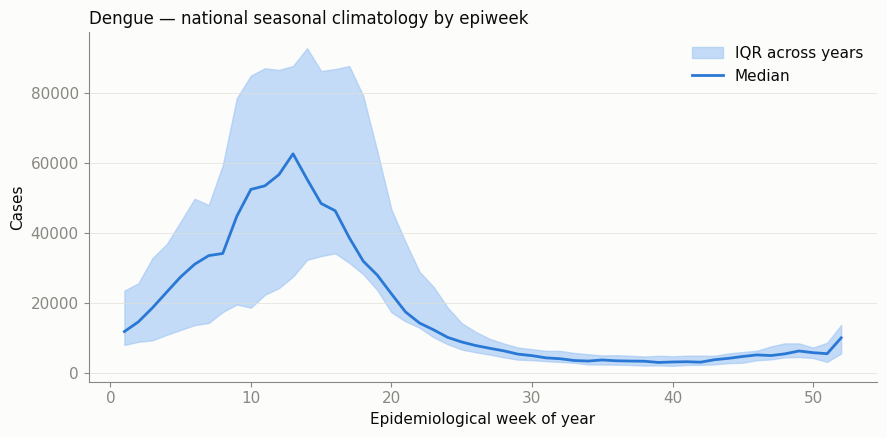

In [3]:
def climatology(national_df):
    df = national_df.copy()
    df["epiweek_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df = df[df["epiweek_of_year"] <= 52]
    g = df.groupby("epiweek_of_year")["casos"]
    return pd.DataFrame({
        "week": g.median().index,
        "median": g.median().values,
        "q25": g.quantile(0.25).values,
        "q75": g.quantile(0.75).values,
    })

clim_dengue = climatology(national_dengue)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(clim_dengue["week"], clim_dengue["q25"], clim_dengue["q75"],
                 color=COLOR_BAND, alpha=0.6, label="IQR across years")
ax.plot(clim_dengue["week"], clim_dengue["median"], color=COLOR_DENGUE, lw=2, label="Median")
ax.set_title("Dengue — national seasonal climatology by epiweek", loc="left", fontsize=12)
ax.set_xlabel("Epidemiological week of year")
ax.set_ylabel("Cases")
ax.legend(frameon=False)
ax.grid(axis="y", lw=0.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dengue_climatology.png", dpi=150)
plt.show()

## 3. State x year incidence heatmap

26 states is too many for a categorical line chart (color-cycling anti-pattern). A sequential one-hue heatmap (state x year, log-scaled annual totals) is the right form for this many categories x magnitude.

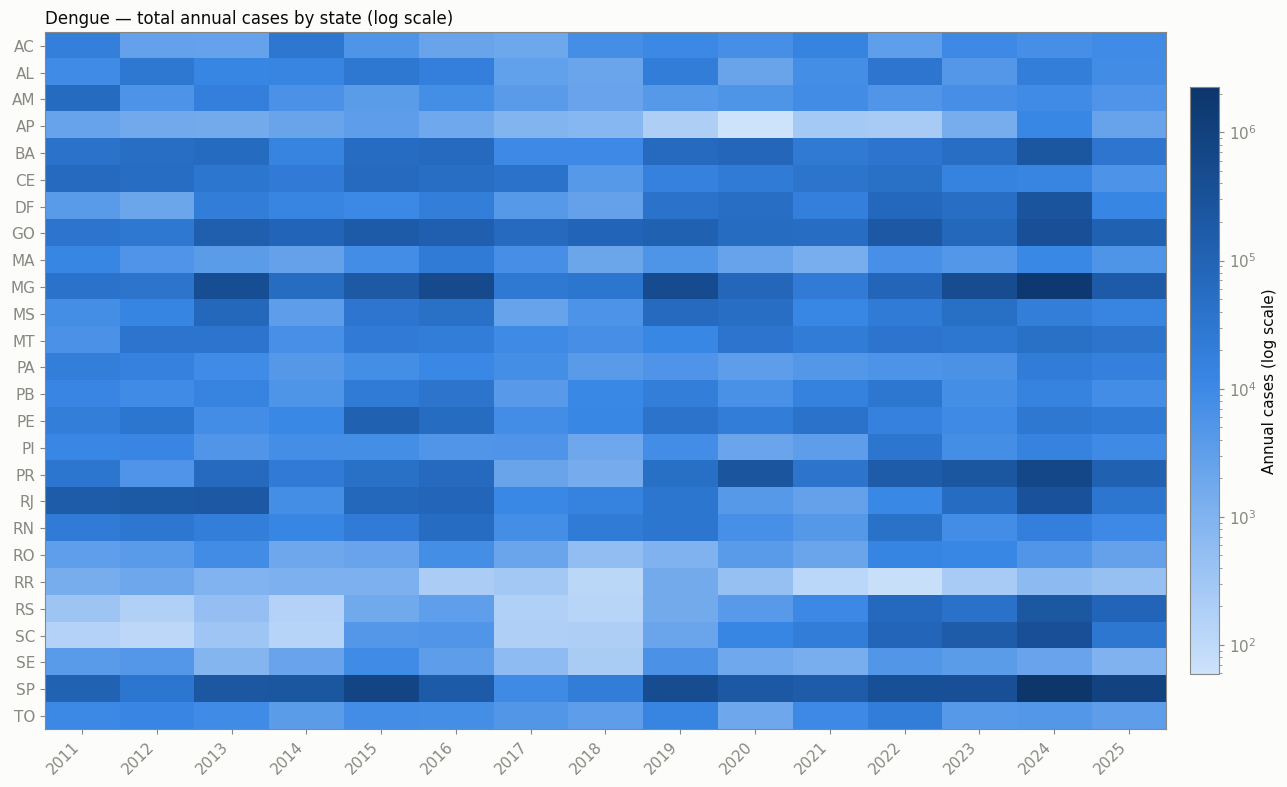

In [4]:
from matplotlib.colors import LinearSegmentedColormap, LogNorm

# One-hue sequential ramp (blue, light->dark) per the project's sequential palette step scale.
seq_hex = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
seq_cmap = LinearSegmentedColormap.from_list("seq_blue", seq_hex)

state_dengue_yearly = state_dengue.copy()
state_dengue_yearly["year"] = state_dengue_yearly["date"].dt.year
pivot = (
    state_dengue_yearly.groupby(["uf", "year"])["casos"].sum()
    .unstack("year")
    .reindex(MANDATORY_UFS)
)
# drop first/last partial years for a fair total
pivot = pivot.drop(columns=[c for c in [2010, 2026] if c in pivot.columns], errors="ignore")

fig, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(pivot.values, aspect="auto", cmap=seq_cmap, norm=LogNorm(vmin=max(pivot.values[pivot.values > 0].min(), 1)))
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_title("Dengue — total annual cases by state (log scale)", loc="left", fontsize=12)
cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Annual cases (log scale)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dengue_state_year_heatmap.png", dpi=150)
plt.show()

## 4. Small multiples — top 6 states by total case volume

Small multiples avoid both the "26 colors on one chart" and "dual axis" anti-patterns when comparing time series across very different scales: each state gets its own panel with its own y-scale, single hue.

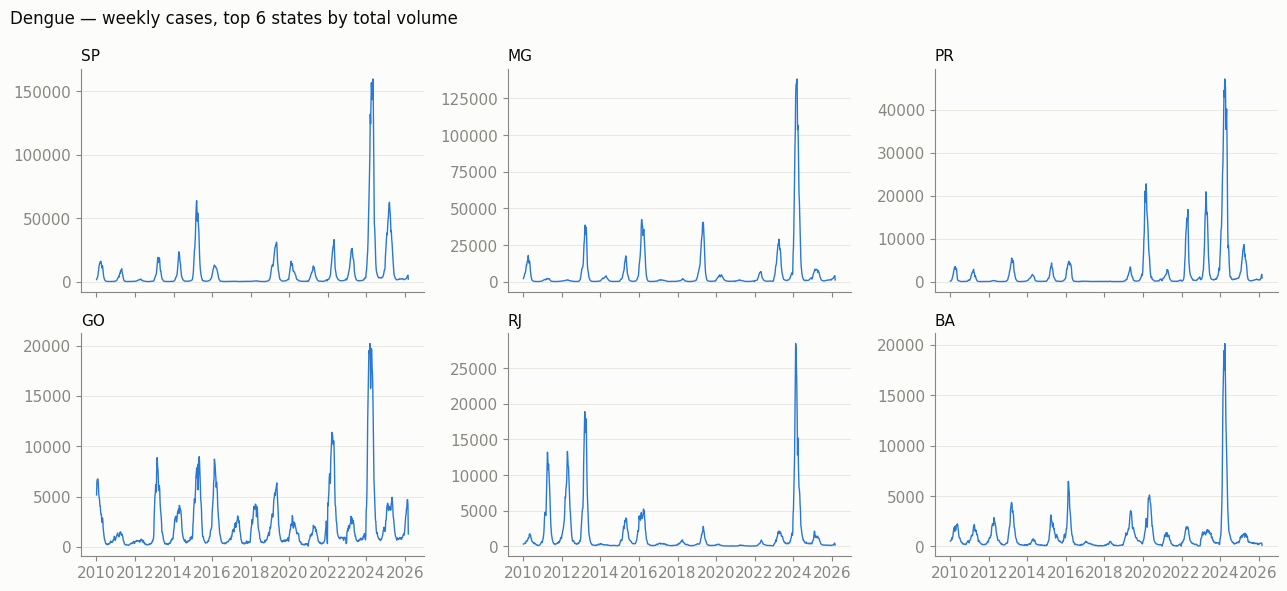

In [5]:
top6 = pivot.sum(axis=1).sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, uf in zip(axes.flat, top6):
    sub = state_dengue[state_dengue["uf"] == uf]
    ax.plot(sub["date"], sub["casos"], color=COLOR_DENGUE, lw=1)
    ax.set_title(uf, loc="left", fontsize=11)
    ax.grid(axis="y", lw=0.5)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
fig.suptitle("Dengue — weekly cases, top 6 states by total volume", x=0.01, ha="left", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dengue_top6_states_small_multiples.png", dpi=150)
plt.show()

## 5. Peak timing across state-seasons

Distribution of the epiweek where each state hits its annual peak, across all state-years — relevant to the paper's peak-timing-error metric and to whether a single national seasonal prior is reasonable or states need individually shifted priors.

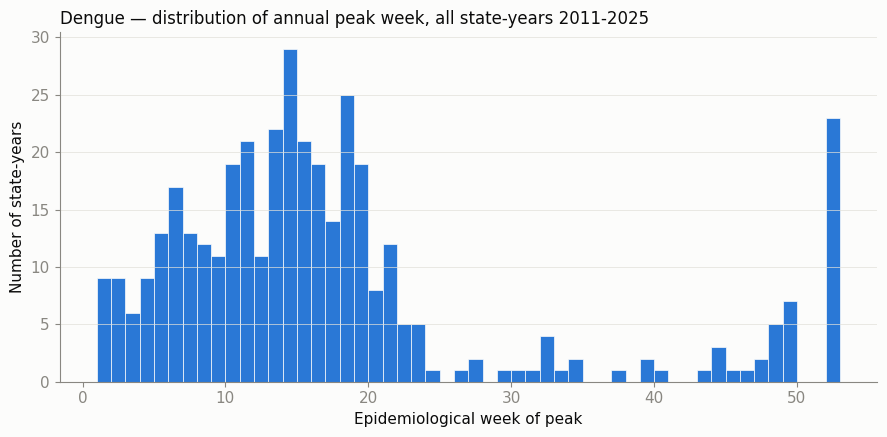

Median peak week: 14, IQR: [9, 19]


In [6]:
sd = state_dengue.copy()
sd["year"] = sd["date"].dt.year
sd["epiweek_of_year"] = sd["date"].dt.isocalendar().week.astype(int)
sd = sd[(sd["year"] >= 2011) & (sd["year"] <= 2025)]  # drop partial first/last years

peak_weeks = sd.loc[sd.groupby(["uf", "year"])["casos"].idxmax()][["uf", "year", "epiweek_of_year", "casos"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(peak_weeks["epiweek_of_year"], bins=52, range=(1, 53), color=COLOR_DENGUE, edgecolor="#fcfcfb", linewidth=0.5)
ax.set_title("Dengue — distribution of annual peak week, all state-years 2011-2025", loc="left", fontsize=12)
ax.set_xlabel("Epidemiological week of peak")
ax.set_ylabel("Number of state-years")
ax.grid(axis="y", lw=0.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dengue_peak_week_distribution.png", dpi=150)
plt.show()

print(f"Median peak week: {peak_weeks['epiweek_of_year'].median():.0f}, "
      f"IQR: [{peak_weeks['epiweek_of_year'].quantile(0.25):.0f}, {peak_weeks['epiweek_of_year'].quantile(0.75):.0f}]")

## 6. Dengue vs. chikungunya — state-level annual totals

Two series -> scatter with a legend-free single-hue treatment isn't right here since we're comparing two diseases per point; use one categorical hue per disease is unnecessary for a scatter of paired totals, so instead plot dengue vs. chikungunya annual totals per state-year as a single-hue scatter (identity is the state label, not needed as color) with a log-log scale given the range.

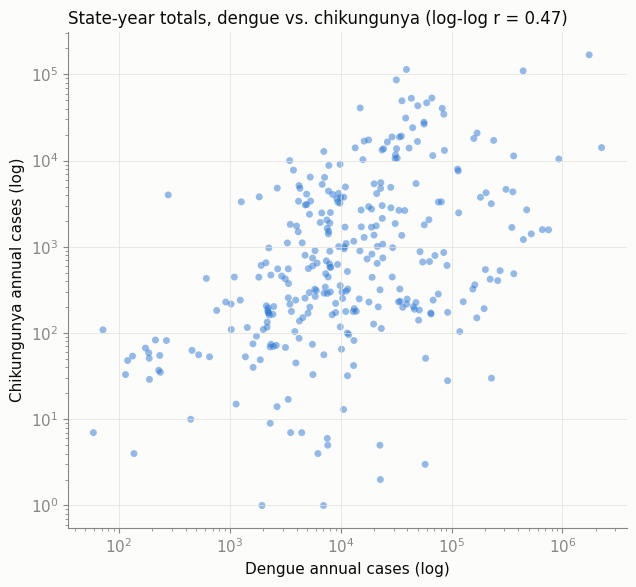

In [7]:
sc = state_chik.copy()
sc["year"] = sc["date"].dt.year
chik_yearly = sc.groupby(["uf", "year"])["casos"].sum().rename("chik_casos")
dengue_yearly = sd.groupby(["uf", "year"])["casos"].sum().rename("dengue_casos")
paired = pd.concat([dengue_yearly, chik_yearly], axis=1).dropna()
paired = paired[(paired["dengue_casos"] > 0) & (paired["chik_casos"] > 0)]

corr = np.corrcoef(np.log1p(paired["dengue_casos"]), np.log1p(paired["chik_casos"]))[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(paired["dengue_casos"], paired["chik_casos"], color=COLOR_DENGUE, alpha=0.5, s=25, edgecolor="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Dengue annual cases (log)")
ax.set_ylabel("Chikungunya annual cases (log)")
ax.set_title(f"State-year totals, dengue vs. chikungunya (log-log r = {corr:.2f})", loc="left", fontsize=12)
ax.grid(lw=0.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dengue_vs_chik_state_year_scatter.png", dpi=150)
plt.show()

## Summary

Key patterns to carry into feature engineering and modeling (fill in specifics after reviewing the rendered figures above):
- Strong, consistent seasonal shape nationally (single annual peak), but peak timing varies across states — supports per-state or per-region seasonal features rather than one national calendar prior.
- Case volume is extremely right-skewed across states (heatmap) — models should work in log/log1p space and metrics should be evaluated relative-to-baseline (WIS ratio) rather than raw scale.
- Dengue and chikungunya are correlated at the state-year level but not 1:1 — worth testing chikungunya as an auxiliary/multi-task signal for dengue forecasting, not just modeling independently.